
📊 CATEGORICAL VARIABLE ANALYSIS: 'Gender'

──────────────────────────────────────────────────────────────────────
📌 PART 1: ANALYSIS INCLUDING MISSING VALUES
──────────────────────────────────────────────────────────────────────

📋 BASIC INFORMATION:
   • Data Type: str
   • Total Records: 301,712
   • Present Values: 301,710
   • Missing Values: 2
   • Missing %: 0.00%
   • Unique Categories: 2

📊 FREQUENCY TABLE (WITH MISSING):
--------------------------------------------------------------------------------
Category  Count  Percentage
    Male 154612       51.25
  Female 147098       48.75
 MISSING      2        0.00

📈 ADDITIONAL STATISTICS:
   • Number of Categories: 2
   • Mode (Most Frequent): Male
   • Mode Count: 154,612 (51.24%)
   • Entropy: 1.000 bits
   • Max Possible Entropy: 1.000 bits
   • Normalized Entropy: 1.000 (0=uniform, 1=concentrated)
   • Distribution: Very evenly distributed

──────────────────────────────────────────────────────────────────────
📌 PART 2: ANAL

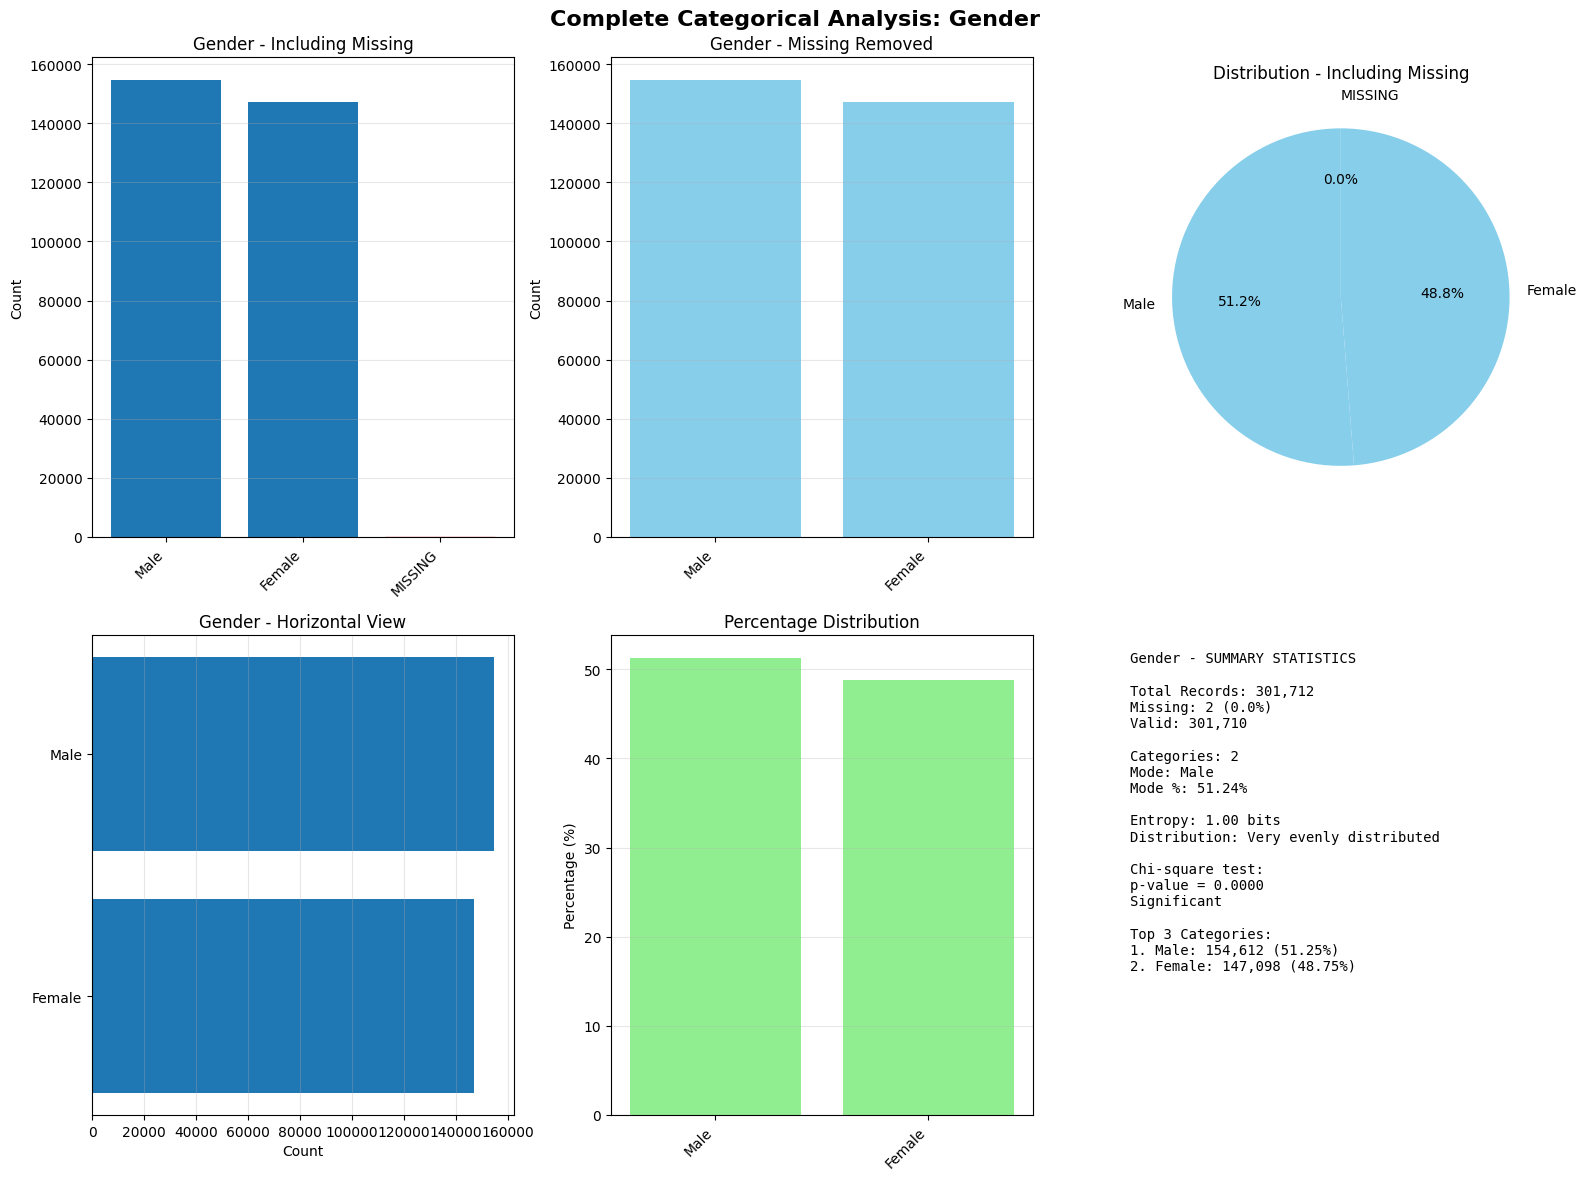


──────────────────────────────────────────────────────────────────────
📌 PART 5: EXPORTING TO EXCEL
──────────────────────────────────────────────────────────────────────
✅ Excel file saved: Gender_categorical_analysis.xlsx

✅ ANALYSIS COMPLETE FOR: 'Gender'

📊 KEY FINDINGS:
   • Total records: 301,712
   • Missing: 2 (0.00%)
   • Categories: 2
   • Most common: 'Male' (154,612 occurrences, 51.2%)
   • Distribution: Very evenly distributed
   • Chi-square test: p=0.0000 (Significant)

📁 FILES CREATED:
   • Excel: Gender_categorical_analysis.xlsx
   • PNG: Gender_categorical_analysis.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Define paths
DATA_PATH = Path("../../data/raw")

# Load data
df = pd.read_excel(DATA_PATH / "2020_Birth_Final.xlsx")

# ============================================
# STEP 1: DEFINE YOUR CATEGORICAL COLUMN HERE (CHANGE THIS ONLY)
# ============================================
COLUMN = 'Gender'  # <--- CHANGE THIS to any categorical column
# ============================================

print(f"\n{'='*70}")
print(f"📊 CATEGORICAL VARIABLE ANALYSIS: '{COLUMN}'")
print(f"{'='*70}")

# Check if column exists
if COLUMN not in df.columns:
    print(f"❌ ERROR: Column '{COLUMN}' not found in dataset!")
    print(f"   Available categorical columns: {df.select_dtypes(include=['object', 'category']).columns.tolist()}")
    exit()

# Get data
data = df[COLUMN]

# ============================================
# PART 1: ANALYSIS INCLUDING MISSING VALUES
# ============================================
print(f"\n{'─'*70}")
print(f"📌 PART 1: ANALYSIS INCLUDING MISSING VALUES")
print(f"{'─'*70}")

# Basic info
print(f"\n📋 BASIC INFORMATION:")
print(f"   • Data Type: {data.dtype}")
print(f"   • Total Records: {len(data):,}")
print(f"   • Present Values: {data.count():,}")
print(f"   • Missing Values: {data.isnull().sum():,}")
print(f"   • Missing %: {(data.isnull().sum()/len(data)*100):.2f}%")
print(f"   • Unique Categories: {data.nunique():,}")

# Frequency table with missing
freq_with_missing = data.value_counts(dropna=True)
pct_with_missing = (data.value_counts(dropna=True, normalize=True) * 100).round(2)

# Add missing as separate row
missing_count = data.isnull().sum()
missing_pct = (missing_count/len(data)*100).round(2)

if missing_count > 0:
    # Create series with missing included
    all_categories = list(freq_with_missing.index) + ['MISSING']
    all_counts = list(freq_with_missing.values) + [missing_count]
    all_pcts = list(pct_with_missing.values) + [missing_pct]
else:
    all_categories = list(freq_with_missing.index)
    all_counts = list(freq_with_missing.values)
    all_pcts = list(pct_with_missing.values)

# Create DataFrame
freq_df_with_missing = pd.DataFrame({
    'Category': all_categories,
    'Count': all_counts,
    'Percentage': all_pcts
})
freq_df_with_missing = freq_df_with_missing.sort_values('Count', ascending=False)

print(f"\n📊 FREQUENCY TABLE (WITH MISSING):")
print("-" * 80)
print(freq_df_with_missing.to_string(index=False))

# Calculate additional statistics
n_categories = len(freq_with_missing)
mode_category = freq_with_missing.index[0] if n_categories > 0 else "N/A"
mode_count = freq_with_missing.values[0] if n_categories > 0 else 0
mode_pct = (mode_count/len(data)*100).round(2)

# Entropy (measure of randomness)
if n_categories > 0:
    probs = freq_with_missing.values / len(data)
    entropy = -sum(p * np.log2(p) for p in probs if p > 0)
    max_entropy = np.log2(n_categories) if n_categories > 0 else 0
    normalized_entropy = entropy/max_entropy if max_entropy > 0 else 0
else:
    entropy = max_entropy = normalized_entropy = 0

print(f"\n📈 ADDITIONAL STATISTICS:")
print(f"   • Number of Categories: {n_categories}")
print(f"   • Mode (Most Frequent): {mode_category}")
print(f"   • Mode Count: {mode_count:,} ({mode_pct}%)")
print(f"   • Entropy: {entropy:.3f} bits")
print(f"   • Max Possible Entropy: {max_entropy:.3f} bits")
print(f"   • Normalized Entropy: {normalized_entropy:.3f} (0=uniform, 1=concentrated)")

if normalized_entropy < 0.3:
    diversity = "Very concentrated (one category dominates)"
elif normalized_entropy < 0.6:
    diversity = "Moderately concentrated"
elif normalized_entropy < 0.8:
    diversity = "Well distributed"
else:
    diversity = "Very evenly distributed"

print(f"   • Distribution: {diversity}")

# ============================================
# PART 2: ANALYSIS AFTER REMOVING MISSING VALUES
# ============================================
print(f"\n{'─'*70}")
print(f"📌 PART 2: ANALYSIS AFTER REMOVING MISSING VALUES")
print(f"{'─'*70}")

# Data without missing
clean_data = data.dropna()
clean_count = len(clean_data)

print(f"\n📋 BASIC INFORMATION (Missing Removed):")
print(f"   • Records Analyzed: {clean_count:,}")
print(f"   • Removed: {missing_count:,} missing records")
print(f"   • Removed %: {missing_pct}%")

# Frequency table without missing
freq_clean = clean_data.value_counts()
pct_clean = (clean_data.value_counts(normalize=True) * 100).round(2)

freq_df_clean = pd.DataFrame({
    'Category': freq_clean.index,
    'Count': freq_clean.values,
    'Percentage': pct_clean.values,
    'Cumulative %': pct_clean.cumsum().values
})
freq_df_clean = freq_df_clean.sort_values('Count', ascending=False)

print(f"\n📊 FREQUENCY TABLE (MISSING REMOVED):")
print("-" * 80)
print(freq_df_clean.to_string(index=False))

# ============================================
# PART 3: STATISTICAL TESTS
# ============================================
print(f"\n{'─'*70}")
print(f"📌 PART 3: STATISTICAL TESTS")
print(f"{'─'*70}")

from scipy.stats import chisquare, chi2_contingency

# Chi-square goodness of fit test (test if categories are equally distributed)
if len(freq_clean) >= 2:
    expected_freq = [clean_count/len(freq_clean)] * len(freq_clean)
    chi2_stat, chi2_p = chisquare(freq_clean.values, f_exp=expected_freq)
    
    print(f"\n🔬 CHI-SQUARE GOODNESS OF FIT TEST:")
    print(f"   • Null Hypothesis: All categories are equally distributed")
    print(f"   • Chi-square statistic: {chi2_stat:.4f}")
    print(f"   • Degrees of freedom: {len(freq_clean)-1}")
    print(f"   • P-value: {chi2_p:.6f}")
    
    if chi2_p < 0.05:
        print(f"   • Conclusion: REJECT null hypothesis - Categories are NOT equally distributed")
        print(f"   • Interpretation: Some categories are significantly more/less frequent")
    else:
        print(f"   • Conclusion: FAIL TO REJECT null hypothesis - Categories may be equally distributed")
        print(f"   • Interpretation: No significant difference in category frequencies")

# Test for association with another categorical variable (if you want to compare two)
# You can uncomment and modify this to test association with another variable
"""
test_var = 'Gender'  # Change this to another categorical variable
if test_var in df.columns and test_var != COLUMN:
    print(f"\n🔬 TESTING ASSOCIATION WITH '{test_var}':")
    
    # Create contingency table
    contingency = pd.crosstab(df[COLUMN], df[test_var])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    print(f"   • Chi-square test of independence")
    print(f"   • Chi-square: {chi2:.4f}")
    print(f"   • P-value: {p:.6f}")
    print(f"   • Degrees of freedom: {dof}")
    
    if p < 0.05:
        print(f"   • Conclusion: Significant association between {COLUMN} and {test_var}")
    else:
        print(f"   • Conclusion: No significant association between {COLUMN} and {test_var}")
"""

# ============================================
# PART 4: VISUALIZATIONS
# ============================================
print(f"\n{'─'*70}")
print(f"📌 PART 4: CREATING VISUALIZATIONS")
print(f"{'─'*70}")

fig = plt.figure(figsize=(16, 12))

# 1. Bar Chart (with missing)
ax1 = plt.subplot(2, 3, 1)
bars = ax1.bar(range(len(freq_df_with_missing)), freq_df_with_missing['Count'])
# Color missing bar differently
for i, cat in enumerate(freq_df_with_missing['Category']):
    if cat == 'MISSING':
        bars[i].set_color('red')
        bars[i].set_alpha(0.7)
ax1.set_xticks(range(len(freq_df_with_missing)))
ax1.set_xticklabels([str(c)[:15] + '...' if len(str(c)) > 15 else str(c) for c in freq_df_with_missing['Category']], 
                    rotation=45, ha='right')
ax1.set_ylabel('Count')
ax1.set_title(f'{COLUMN} - Including Missing')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Bar Chart (without missing)
ax2 = plt.subplot(2, 3, 2)
bars2 = ax2.bar(range(len(freq_df_clean)), freq_df_clean['Count'], color='skyblue')
ax2.set_xticks(range(len(freq_df_clean)))
ax2.set_xticklabels([str(c)[:15] + '...' if len(str(c)) > 15 else str(c) for c in freq_df_clean['Category']], 
                    rotation=45, ha='right')
ax2.set_ylabel('Count')
ax2.set_title(f'{COLUMN} - Missing Removed')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Pie Chart (with missing)
ax3 = plt.subplot(2, 3, 3)
if len(freq_df_with_missing) > 5:
    # Group small categories for pie chart
    top5 = freq_df_with_missing.head(5)
    others = pd.DataFrame([{
        'Category': 'Others',
        'Count': freq_df_with_missing[5:]['Count'].sum(),
        'Percentage': freq_df_with_missing[5:]['Percentage'].sum()
    }])
    pie_data = pd.concat([top5, others], ignore_index=True)
else:
    pie_data = freq_df_with_missing

# Explode missing slice
explode = [0.1 if cat == 'MISSING' else 0 for cat in pie_data['Category']]
colors = ['red' if cat == 'MISSING' else 'skyblue' for cat in pie_data['Category']]

ax3.pie(pie_data['Count'], labels=pie_data['Category'], autopct='%1.1f%%',
        startangle=90, explode=explode, colors=colors)
ax3.set_title(f'Distribution - Including Missing')

# 4. Horizontal Bar Chart (sorted)
ax4 = plt.subplot(2, 3, 4)
sorted_data = freq_df_clean.sort_values('Count')
y_pos = np.arange(len(sorted_data))
bars4 = ax4.barh(y_pos, sorted_data['Count'])
ax4.set_yticks(y_pos)
ax4.set_yticklabels([str(c)[:20] + '...' if len(str(c)) > 20 else str(c) for c in sorted_data['Category']])
ax4.set_xlabel('Count')
ax4.set_title(f'{COLUMN} - Horizontal View')
ax4.grid(True, alpha=0.3, axis='x')

# 5. Percentage Bar Chart
ax5 = plt.subplot(2, 3, 5)
bars5 = ax5.bar(range(len(freq_df_clean)), freq_df_clean['Percentage'], color='lightgreen')
ax5.set_xticks(range(len(freq_df_clean)))
ax5.set_xticklabels([str(c)[:10] + '...' if len(str(c)) > 10 else str(c) for c in freq_df_clean['Category']], 
                    rotation=45, ha='right')
ax5.set_ylabel('Percentage (%)')
ax5.set_title('Percentage Distribution')
ax5.grid(True, alpha=0.3, axis='y')

# 6. Statistics Text
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
stats_text = f"""
{COLUMN} - SUMMARY STATISTICS

Total Records: {len(data):,}
Missing: {missing_count:,} ({missing_pct:.1f}%)
Valid: {clean_count:,}

Categories: {n_categories}
Mode: {mode_category}
Mode %: {mode_pct}%

Entropy: {entropy:.2f} bits
Distribution: {diversity}

Chi-square test:
p-value = {chi2_p:.4f}
{'Significant' if chi2_p < 0.05 else 'Not Significant'}

Top 3 Categories:
"""
# Add top 3 categories
for i in range(min(3, len(freq_df_clean))):
    stats_text += f"{i+1}. {freq_df_clean.iloc[i]['Category']}: {freq_df_clean.iloc[i]['Count']:,} ({freq_df_clean.iloc[i]['Percentage']}%)\n"

ax6.text(0, 1, stats_text, fontsize=10, verticalalignment='top', family='monospace')

plt.suptitle(f'Complete Categorical Analysis: {COLUMN}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{COLUMN}_categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# PART 5: EXPORT TO EXCEL
# ============================================
print(f"\n{'─'*70}")
print(f"📌 PART 5: EXPORTING TO EXCEL")
print(f"{'─'*70}")

excel_filename = f'{COLUMN}_categorical_analysis.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    
    # Sheet 1: Summary
    summary_data = {
        'Metric': [
            'Variable Name', 'Data Type', 'Total Records', 'Valid Records', 
            'Missing Records', 'Missing Percentage', 'Number of Categories',
            'Mode (Most Frequent)', 'Mode Count', 'Mode Percentage',
            'Second Most Frequent', 'Third Most Frequent',
            'Entropy (bits)', 'Normalized Entropy', 'Distribution Type',
            'Chi-square Statistic', 'Chi-square P-value', 'Significant?'
        ],
        'Value': [
            COLUMN,
            str(data.dtype),
            f"{len(data):,}",
            f"{clean_count:,}",
            f"{missing_count:,}",
            f"{missing_pct:.2f}%",
            n_categories,
            str(mode_category),
            f"{mode_count:,}",
            f"{mode_pct:.2f}%",
            str(freq_df_clean.iloc[1]['Category']) if len(freq_df_clean) > 1 else 'N/A',
            str(freq_df_clean.iloc[2]['Category']) if len(freq_df_clean) > 2 else 'N/A',
            f"{entropy:.3f}",
            f"{normalized_entropy:.3f}",
            diversity,
            f"{chi2_stat:.4f}" if len(freq_clean) >= 2 else 'N/A',
            f"{chi2_p:.6f}" if len(freq_clean) >= 2 else 'N/A',
            'YES' if chi2_p < 0.05 else 'NO' if len(freq_clean) >= 2 else 'N/A'
        ]
    }
    pd.DataFrame(summary_data).to_excel(writer, sheet_name='Summary', index=False)
    
    # Sheet 2: Frequency Table (with missing)
    freq_df_with_missing.to_excel(writer, sheet_name='Frequency_With_Missing', index=False)
    
    # Sheet 3: Frequency Table (without missing)
    freq_df_clean.to_excel(writer, sheet_name='Frequency_Clean', index=False)
    
    # Sheet 4: Detailed Statistics
    detailed = pd.DataFrame({
        'Category': freq_df_clean['Category'],
        'Count': freq_df_clean['Count'],
        'Percentage': freq_df_clean['Percentage'],
        'Cumulative %': freq_df_clean['Cumulative %'],
        'Rank': range(1, len(freq_df_clean) + 1),
        'Frequency per 1000': (freq_df_clean['Count'] / clean_count * 1000).round(1),
        'Log Count': np.log1p(freq_df_clean['Count']).round(2)
    })
    detailed.to_excel(writer, sheet_name='Detailed_Stats', index=False)

print(f"✅ Excel file saved: {excel_filename}")

# ============================================
# PART 6: PRINT FINAL SUMMARY
# ============================================
print(f"\n{'='*70}")
print(f"✅ ANALYSIS COMPLETE FOR: '{COLUMN}'")
print(f"{'='*70}")
print(f"\n📊 KEY FINDINGS:")
print(f"   • Total records: {len(data):,}")
print(f"   • Missing: {missing_count:,} ({missing_pct:.2f}%)")
print(f"   • Categories: {n_categories}")
print(f"   • Most common: '{mode_category}' ({mode_count:,} occurrences, {mode_pct:.1f}%)")
print(f"   • Distribution: {diversity}")
if len(freq_clean) >= 2:
    print(f"   • Chi-square test: p={chi2_p:.4f} ({'Significant' if chi2_p < 0.05 else 'Not significant'})")
print(f"\n📁 FILES CREATED:")
print(f"   • Excel: {excel_filename}")
print(f"   • PNG: {COLUMN}_categorical_analysis.png")
print(f"{'='*70}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

In [3]:
# Define paths
DATA_PATH = Path("../../data/raw")

# Load data
df = pd.read_excel(DATA_PATH / "2020_Birth_Final.xlsx")
